# LinkedIn Job Trend Analysis



---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# load the dataset
df = pd.read_csv('linkedin_jobs_data.csv')
print(f"Loaded {len(df)} job postings. Here's a quick peek:")
display(df.head())

Loaded 1030 job postings. Here's a quick peek:


,Title,Company,Location,Link,Skills_Raw,Job_ID
0,Data Analyst,Marathon Petroleum Corporation,"Findlay, OH",https://www.linkedin.com/jobs/view/data-analys...,"Machine Learning, Python, Excel, Tableau",NaN
1,Data Analyst,Marathon Petroleum Corporation,"San Antonio, TX",https://www.linkedin.com/jobs/view/data-analys...,"Machine Learning, Excel, Pandas",NaN
2,Data Analyst | Remote,Crossing Hurdles,United States,https://www.linkedin.com/jobs/view/data-analys...,"Tableau, Statistics, AWS, Power BI",NaN
3,"Data Analyst – Operations: Manhattan, NY",CAVA,"Manhattan, NY",https://www.linkedin.com/jobs/view/data-analys...,"Pandas, Tableau, AWS, R",NaN
4,Reporting Analyst | Remote,Crossing Hurdles,United States,https://www.linkedin.com/jobs/view/reporting-a...,"Machine Learning, Python, Statistics, AWS, Tab...",NaN


## 1. Cleaning and Parsing Skill Tags


In [ ]:
# Function to clean individual skill strings
def clean_skill(skill):
    skill = str(skill).strip().title() # standardizes casing (e.g., 'python' -> 'Python')
    skill = skill.replace(' 3', '') # Removes version numbers like 'Python 3' to group them properly
    return skill

# Split the string into a list of skills
df['Skills_List'] = df['Skills_Raw'].apply(lambda x: [clean_skill(s) for s in str(x).split(',') if s.strip()])

# Explode the lists so each row has exactly one skill. This is crucial for counting!
df_exploded = df.explode('Skills_List').rename(columns={'Skills_List': 'Skill'})
df_exploded = df_exploded.dropna(subset=['Skill'])
df_exploded = df_exploded.reset_index(drop=True) # Reset index to avoid duplicate label issues later

print("Skills cleaned and parsed! Exploded dataset shape:", df_exploded.shape)

Skills cleaned and parsed! Exploded dataset shape: (4612, 7)


## 2. Heatmap: Top 10 Skills by City


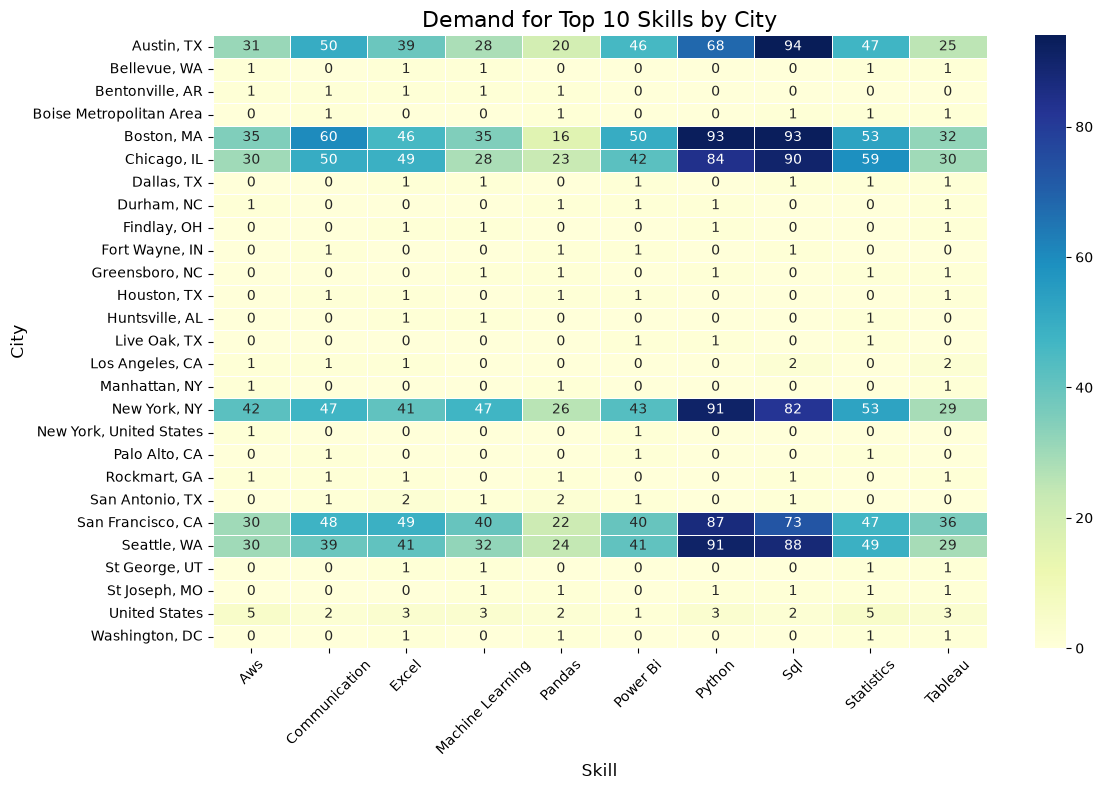

In [ ]:
# Find the top 10 most requested skills overall
top_10_skills = df_exploded['Skill'].value_counts().nlargest(10).index

# Filter data for only these top 10 skills
df_top_skills = df_exploded[df_exploded['Skill'].isin(top_10_skills)].copy()

# Create a pivot table: Cities as rows, Skills as columns, count of jobs as values
city_skill_matrix = pd.crosstab(df_top_skills['Location'], df_top_skills['Skill'])

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(city_skill_matrix, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title('Demand for Top 10 Skills by City', fontsize=16)
plt.xlabel('Skill', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Top_10_Skills_Heatmap.png') # Saving the visual for the user
plt.show()

## 3. Skill vs Role Matrix


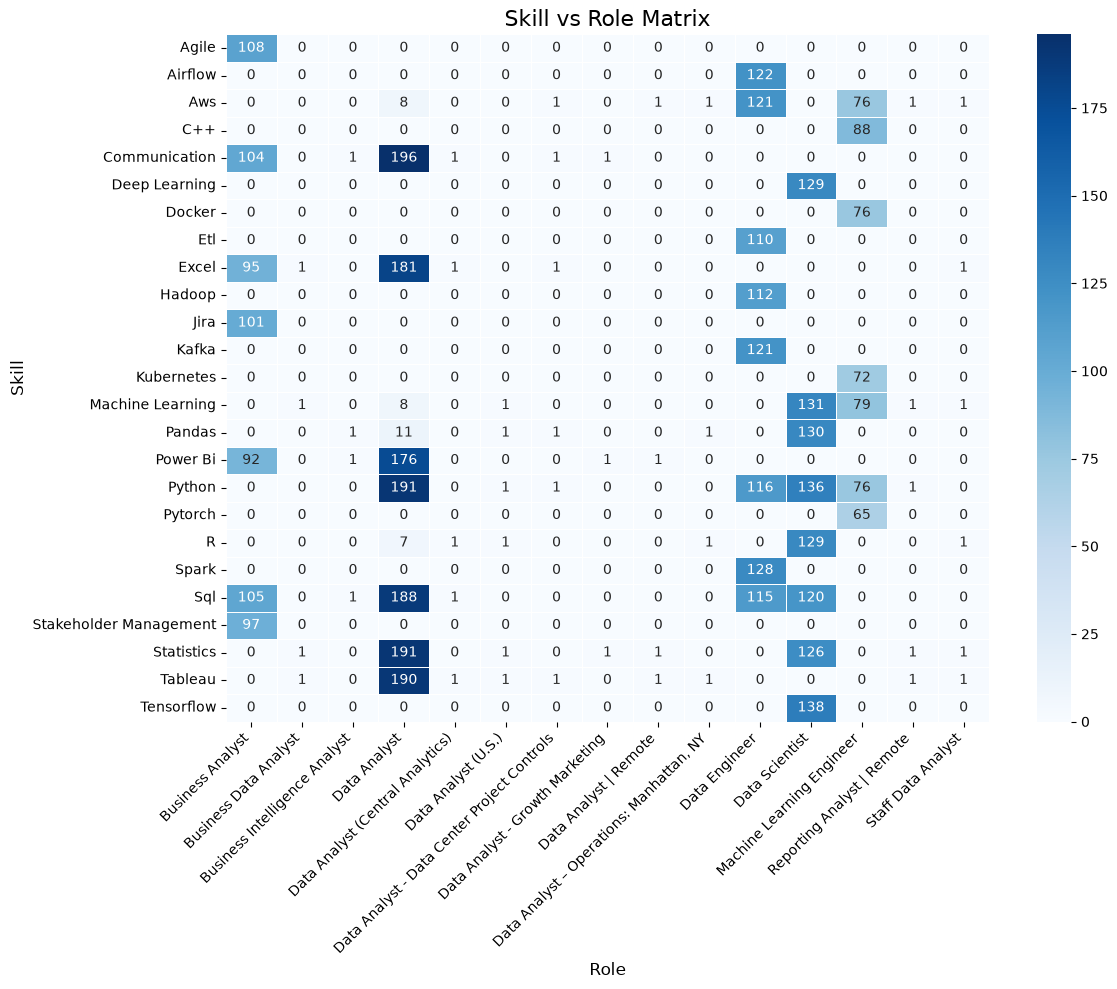


Awesome! Skill vs Role matrix exported to 'Skill_Role_Matrix.xlsx'.


In [ ]:
# Create the Skill vs Role Matrix
skill_role_matrix = pd.crosstab(df_exploded['Skill'], df_exploded['Title'])

# Let's visualize it as another heatmap just because it looks great
plt.figure(figsize=(12, 10))
sns.heatmap(skill_role_matrix, annot=True, fmt="d", cmap="Blues", linewidths=.5)
plt.title('Skill vs Role Matrix', fontsize=16)
plt.xlabel('Role', fontsize=12)
plt.ylabel('Skill', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Skill_Role_Matrix.png')
plt.show()

# Finally, export this matrix to Excel as requested by the user
excel_path = 'Skill_Role_Matrix.xlsx'
skill_role_matrix.to_excel(excel_path)
print(f"\nAwesome! Skill vs Role matrix exported to '{excel_path}'.")